<a href="https://colab.research.google.com/github/Alexandre77777/computer_math/blob/main/9.%20%D0%93%D0%B5%D0%BD%D0%B5%D1%80%D0%B0%D1%86%D0%B8%D1%8F%20%D1%81%D0%B8%D0%B3%D0%BD%D0%B0%D0%BB%D0%BE%D0%B2%20%D0%B8%20%D0%BF%D1%80%D0%B5%D0%BE%D0%B1%D1%80%D0%B0%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D1%8F%20%D0%A4%D1%83%D1%80%D1%8C%D0%B5/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%969_%D0%93%D0%B5%D0%BD%D0%B5%D1%80%D0%B0%D1%86%D0%B8%D1%8F_%D1%81%D0%B8%D0%B3%D0%BD%D0%B0%D0%BB%D0%BE%D0%B2_%D0%B8_%D0%BF%D1%80%D0%B5%D0%BE%D0%B1%D1%80%D0%B0%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D1%8F_%D0%A4%D1%83%D1%80%D1%8C%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №9. Генерация сигналов и преобразования Фурье

# Блок №1. Базовый уровень

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from scipy.signal import spectrogram

## **Задание 1: Генерация сигналов**



В этом задании вам нужно создать различные виды сигналов. Сигналы являются основой цифровой обработки сигналов, и умение их генерировать является важным навыком.













1. **Синусоидальный сигнал**: Синусоидальный сигнал можно представить как $A \sin(2\pi ft + \phi)$, где $A$ - амплитуда, $f$ - частота, $\phi$ - фаза.

- Создайте функцию, которая принимает эти параметры, а также длительность сигнала, и возвращает сгенерированный сигнал.

### Пример:



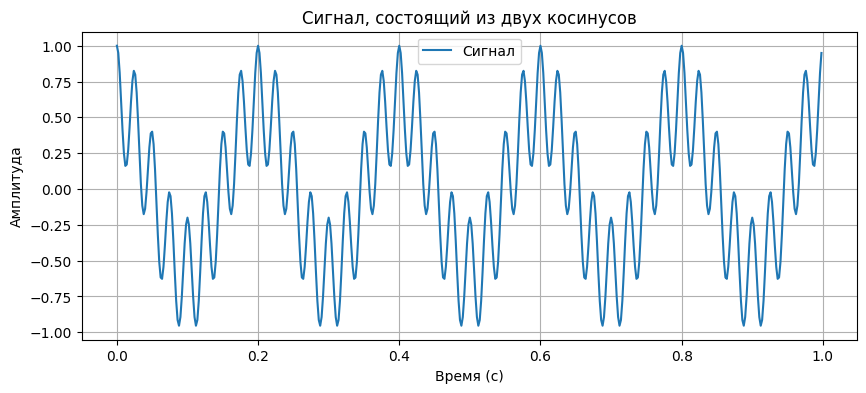

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Параметры времени
T = 1.0         # длительность сигнала в секундах
fs = 500.0      # частота дискретизации (в герцах)
t = np.arange(0, T, 1/fs) # массив времени

# Создание сигнала
f1 = 5.0        # частота первого косинуса
f2 = 40.0       # частота второго косинуса
a1 = 0.6        # амплитуда первого косинуса
a2 = 0.4        # амплитуда второго косинуса
signal = a1*np.cos(2*np.pi*f1*t) + a2*np.cos(2*np.pi*f2*t)

# Визуализация сигнала
plt.figure(figsize=(10, 4))
plt.plot(t, signal, label='Сигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Cигнал, состоящий из двух косинусов')
plt.legend()
plt.grid(True)
plt.show()


### Ваш код:

In [ ]:
def sine_wave(amplitude, frequency, phase, duration, fs=1000):
    """Синусоидальный сигнал A*sin(2*pi*f*t + phi). Возвращает (t, сигнал)."""
    t = np.arange(0, duration, 1 / fs)
    return t, amplitude * np.sin(2 * np.pi * frequency * t + phase)

In [ ]:
# Пример: синусоида 5 Гц, амплитуда 1, фаза 0, длительность 1 с
t1, sig1 = sine_wave(1.0, 5, 0, 1.0)

plt.figure(figsize=(10, 3.5))
plt.plot(t1, sig1)
plt.title('Синусоидальный сигнал (f = 5 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

2. **Сумма синусоид**: Сигнал, состоящий из суммы двух синусоид, можно представить как $A_1 \sin(2\pi f_1t + \phi_1) + A_2 \sin(2\pi f_2t + \phi_2)$.

- Создайте функцию, которая принимает параметры для двух синусоид, а также длительность сигнала, и возвращает сгенерированный сигнал.

In [ ]:
def two_sine_waves(a1, f1, phi1, a2, f2, phi2, duration, fs=1000):
    """Сумма двух синусоид. Возвращает (t, сигнал)."""
    t = np.arange(0, duration, 1 / fs)
    return t, a1 * np.sin(2 * np.pi * f1 * t + phi1) + a2 * np.sin(2 * np.pi * f2 * t + phi2)

In [ ]:
# Пример: 5 Гц + 40 Гц
t2, sig2 = two_sine_waves(1.0, 5, 0, 0.5, 40, 0, 1.0)

plt.figure(figsize=(10, 3.5))
plt.plot(t2, sig2)
plt.title('Сумма двух синусоид (5 Гц и 40 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

3. **Шумовой сигнал**: Шумовой сигнал (или белый шум) можно сгенерировать как случайные значения из нормального распределения.

- Создайте функцию, которая принимает амплитуду шума и длительность сигнала, и возвращает сгенерированный шумовой сигнал.

In [ ]:
def noise_wave(amplitude, duration, fs=1000):
    """Белый шум: нормально распределенные значения с масштабом amplitude."""
    t = np.arange(0, duration, 1 / fs)
    return t, amplitude * np.random.normal(0, 1, len(t))

In [ ]:
# Пример: шум с амплитудой 0.5
np.random.seed(0)
t3, sig3 = noise_wave(0.5, 1.0)

plt.figure(figsize=(10, 3.5))
plt.plot(t3, sig3)
plt.title('Шумовой сигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

4. **Синусоида плюс шум**: Сигнал, который представляет собой сумму синусоиды и шума, можно сгенерировать путем сложения синусоидального и шумового сигналов.
- Создайте функцию, которая принимает параметры для синусоиды и шума, а также длительность сигнала, и возвращает сгенерированный сигнал.

In [ ]:
def sine_plus_noise(amplitude, frequency, phase, noise_amplitude, duration, fs=1000):
    """Синусоида + белый шум. Возвращает (t, сигнал)."""
    t, s = sine_wave(amplitude, frequency, phase, duration, fs)
    _, n = noise_wave(noise_amplitude, duration, fs)
    return t, s + n

In [ ]:
# Пример: синусоида 10 Гц + шум
np.random.seed(0)
t4, sig4 = sine_plus_noise(1.0, 10, 0, 0.5, 1.0)

plt.figure(figsize=(10, 3.5))
plt.plot(t4, sig4)
plt.title('Синусоида (10 Гц) + шум')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

## **Задание 2: Преобразование Фурье**


Преобразование Фурье позволяет перейти от временного представления сигнала к частотному. Это основной инструмент для анализа сигналов. Создайте функцию, которая принимает сигнал и возвращает его преобразование Фурье.


1. Примените преобразование Фурье к синусоидальному сигналу и визуализируйте результат.


In [ ]:
FS = 1000   # частота дискретизации, Гц

def compute_spectrum(sig, fs=FS):
    """Одностороннее амплитудное спектральное представление сигнала (через БПФ)."""
    n = len(sig)
    yf = fft(sig)
    freqs = fftfreq(n, 1 / fs)[:n // 2]
    amplitude = 2.0 / n * np.abs(yf[:n // 2])
    return freqs, amplitude

def plot_time_and_spectrum(t, sig, title, fs=FS, xlim=None):
    freqs, amp = compute_spectrum(sig, fs)
    fig, axes = plt.subplots(2, 1, figsize=(10, 6))
    axes[0].plot(t, sig)
    axes[0].set_title(f'{title}: временная область')
    axes[0].set_xlabel('Время (с)')
    axes[0].set_ylabel('Амплитуда')
    axes[0].grid(True)
    axes[1].plot(freqs, amp)
    axes[1].set_title(f'{title}: спектр')
    axes[1].set_xlabel('Частота (Гц)')
    axes[1].set_ylabel('Амплитуда')
    axes[1].grid(True)
    if xlim:
        axes[1].set_xlim(xlim)
    plt.tight_layout()
    plt.show()
    return freqs, amp

# Синусоидальный сигнал 5 Гц
t_a, sig_a = sine_wave(1.0, 5, 0, 1.0, FS)

In [ ]:
# Пример: спектр синусоиды - один пик на частоте 5 Гц
freqs, amp = plot_time_and_spectrum(t_a, sig_a, 'Синусоида 5 Гц', xlim=(0, 50))
print(f"Пик спектра на частоте {freqs[np.argmax(amp)]:.1f} Гц, амплитуда {amp.max():.3f}")

2. Примените преобразование Фурье к сигналу, состоящему из суммы двух синусоид, и визуализируйте результат.


In [ ]:
# Сумма двух синусоид: 5 Гц (A = 1) и 40 Гц (A = 0.5)
t_b, sig_b = two_sine_waves(1.0, 5, 0, 0.5, 40, 0, 1.0, FS)

In [ ]:
# Пример: в спектре два пика - на 5 и 40 Гц
freqs, amp = plot_time_and_spectrum(t_b, sig_b, 'Сумма двух синусоид', xlim=(0, 100))
top2 = np.sort(freqs[np.argsort(amp)[-2:]])
print("Две наибольшие частоты в спектре, Гц:", top2)

3. Примените преобразование Фурье к шумовому сигналу и визуализируйте результат.


In [ ]:
# Шумовой сигнал
np.random.seed(1)
t_c, sig_c = noise_wave(0.5, 1.0, FS)

In [ ]:
# Пример: спектр белого шума примерно равномерный (нет выделенных пиков)
freqs, amp = plot_time_and_spectrum(t_c, sig_c, 'Белый шум')
print(f"Средняя амплитуда спектра: {amp.mean():.4f}, максимальная: {amp.max():.4f}")

4. Примените преобразование Фурье к сигналу, который представляет собой сумму синусоиды и шума, и визуализируйте результат.

In [ ]:
# Синусоида 10 Гц + шум
np.random.seed(2)
t_d, sig_d = sine_plus_noise(1.0, 10, 0, 0.5, 1.0, FS)

In [ ]:
# Пример: на фоне "шумового пола" виден четкий пик на частоте 10 Гц
freqs, amp = plot_time_and_spectrum(t_d, sig_d, 'Синусоида (10 Гц) + шум')
print(f"Основной пик на частоте {freqs[np.argmax(amp)]:.1f} Гц")

## **Задание 3: Фильтрация сигналов**

Фильтрация сигналов позволяет улучшить качество сигнала, убрав нежелательные частоты. Создайте функцию, которая принимает сигнал и частоту среза, и возвращает отфильтрованный сигнал.




1. Создайте функцию для фильтрации сигнала с использованием преобразования Фурье.

In [ ]:
def lowpass_filter(sig, cutoff, fs=FS):
    """ФНЧ через преобразование Фурье: обнуляем все частоты выше частоты среза."""
    n = len(sig)
    yf = fft(sig)
    freqs = fftfreq(n, 1 / fs)
    yf[np.abs(freqs) > cutoff] = 0        # учитываем и отрицательные частоты
    return np.real(ifft(yf))

In [ ]:
# Пример: сигнал 10 Гц + 120 Гц; частота среза 50 Гц оставляет только низкочастотную часть
_, low = sine_wave(1.0, 10, 0, 1.0, FS)
_, high = sine_wave(0.5, 120, 0, 1.0, FS)
mixed = low + high
filtered = lowpass_filter(mixed, cutoff=50)
print("Максимальное отличие отфильтрованного сигнала от чистой синусоиды 10 Гц:",
      f"{np.abs(filtered - low).max():.2e}")

2. Примените эту функцию к сигналу, который представляет собой сумму синусоиды и шума, и визуализируйте результаты до и после фильтрации.

In [ ]:
# Применяем фильтр к сумме синусоиды и шума
np.random.seed(3)
t_e, noisy = sine_plus_noise(1.0, 10, 0, 0.7, 1.0, FS)
_, clean = sine_wave(1.0, 10, 0, 1.0, FS)
denoised = lowpass_filter(noisy, cutoff=30)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t_e, noisy, label='Исходный зашумленный сигнал', alpha=0.7)
axes[0].set_title('До фильтрации')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(t_e, denoised, label='После фильтрации (fc = 30 Гц)')
axes[1].plot(t_e, clean, '--', label='Чистая синусоида', alpha=0.7)
axes[1].set_title('После фильтрации')
axes[1].set_xlabel('Время (с)')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Пример: сравнение среднеквадратичной ошибки относительно чистой синусоиды
rmse_before = np.sqrt(np.mean((noisy - clean) ** 2))
rmse_after = np.sqrt(np.mean((denoised - clean) ** 2))
print(f"RMSE до фильтрации   : {rmse_before:.4f}")
print(f"RMSE после фильтрации: {rmse_after:.4f}")

fr1, a1 = compute_spectrum(noisy)
fr2, a2 = compute_spectrum(denoised)
plt.figure(figsize=(10, 3.5))
plt.plot(fr1, a1, label='до', alpha=0.7)
plt.plot(fr2, a2, label='после')
plt.title('Спектр до и после фильтрации')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True)
plt.show()

## **Задание 4: Анализ сигналов**

Анализ сигналов включает в себя различные методы и техники для изучения и понимания сигналов. Создайте функцию, которая принимает сигнал и возвращает его спектрограмму (**scipy.signal.spectrogram**).


**Спектрограмма** - это визуальное представление спектра частот сигнала во времени. Она показывает, какие частоты присутствуют в сигнале в каждый момент времени. Вот как правильно понимать спектрограмму:

- **Ось X**: Это время. Она показывает продолжительность сигнала. Каждый столбец на спектрограмме представляет собой отдельный момент времени.

- **Ось Y**: Это частота. Она показывает различные частоты, которые присутствуют в сигнале. Каждая строка на спектрограмме представляет собой отдельную частоту.

- **Значение**: Значение в каждой точке (x, y) показывает амплитуду (или интенсивность) данной частоты в данное время. Обычно более яркие цвета означают большую амплитуду, а более темные цвета - меньшую амплитуду.

Таким образом, спектрограмма позволяет вам видеть, как меняется спектральный состав сигнала во времени. Это может быть полезно во многих областях, включая анализ речи, музыку, радиосигналы и многое другое. Например, в анализе речи вы можете видеть, как меняются форманты (основные частоты) во время произношения различных звуков. В музыке вы можете видеть, как меняются ноты во время проигрывания песни.

1. Создайте функцию для вычисления и визуализации спектрограммы сигнала.


In [ ]:
from scipy import signal as sps   # сигналы выше могли перекрыть имя signal, поэтому используем псевдоним

def plot_spectrogram(sig, fs=FS, title='Спектрограмма', nperseg=128):
    """Вычисляет и рисует спектрограмму сигнала (scipy.signal.spectrogram)."""
    f, t, Sxx = sps.spectrogram(sig, fs=fs, nperseg=nperseg, noverlap=nperseg // 2)
    plt.figure(figsize=(9, 4))
    plt.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-12), shading='gouraud')
    plt.colorbar(label='Мощность, дБ')
    plt.title(title)
    plt.xlabel('Время (с)')
    plt.ylabel('Частота (Гц)')
    plt.show()
    return f, t, Sxx

2. Примените эту функцию к различным сигналам, которые вы сгенерировали и проанализировали в предыдущих заданиях.

In [ ]:
# Применяем к ранее сгенерированным сигналам
for name, sig in [('Синусоида 5 Гц', sig_a),
                  ('Сумма двух синусоид (5 и 40 Гц)', sig_b),
                  ('Белый шум', sig_c),
                  ('Синусоида + шум', sig_d)]:
    plot_spectrogram(sig, title=f'Спектрограмма: {name}')

In [ ]:
# Пример: сигнал с меняющейся частотой (chirp) - на спектрограмме видна наклонная линия
t_ch = np.arange(0, 2, 1 / FS)
chirp_sig = sps.chirp(t_ch, f0=10, t1=2, f1=300, method='linear')
plot_spectrogram(chirp_sig, title='Спектрограмма: chirp 10 -> 300 Гц')

# Блок №2. Повышенный уровень

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from scipy.io import wavfile

## **Задание 1: Чтение и визуализация звукового файла**











В этом задании вам нужно использовать функцию `wavfile.read` из модуля `scipy.io` для чтения звукового файла. Эта функция возвращает частоту дискретизации и данные аудиосигнала. Затем вы должны визуализировать эти данные с помощью `matplotlib.pyplot.plot`. В результате вы получите график амплитуды звукового сигнала во времени.

1. Используйте библиотеку `scipy.io.wavfile` для чтения звукового файла.

In [ ]:
import os
from scipy.io import wavfile

wav_path = 'sound.wav'    # укажите путь к своему WAV-файлу (загрузите его в Colab)

if not os.path.exists(wav_path):
    # Своего файла нет - создаем тестовый: тон 440 Гц + высокочастотный тон 3000 Гц + шум
    rate_demo = 22050
    t_demo = np.arange(0, 3, 1 / rate_demo)
    demo = (0.5 * np.sin(2 * np.pi * 440 * t_demo)
            + 0.3 * np.sin(2 * np.pi * 3000 * t_demo)
            + 0.05 * np.random.normal(size=len(t_demo)))
    wavfile.write(wav_path, rate_demo, (demo * 32767 / np.abs(demo).max()).astype(np.int16))
    print("Файл sound.wav не найден - создан тестовый файл.")

sample_rate, data = wavfile.read(wav_path)
if data.ndim > 1:                 # стерео -> берем один канал
    data = data[:, 0]
data = data.astype(np.float64)

print(f"Частота дискретизации: {sample_rate} Гц")
print(f"Число отсчетов: {len(data)}, длительность: {len(data) / sample_rate:.2f} с")

2. Визуализируйте временную форму звукового сигнала.

In [ ]:
time_axis = np.arange(len(data)) / sample_rate

plt.figure(figsize=(11, 4))
plt.plot(time_axis, data)
plt.title('Временная форма звукового сигнала')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

In [ ]:
# Пример: увеличенный фрагмент (первые 10 мс) - видна форма колебаний
n10 = int(0.01 * sample_rate)
plt.figure(figsize=(11, 3.5))
plt.plot(time_axis[:n10], data[:n10])
plt.title('Первые 10 мс сигнала')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

## **Задание 2: Применение преобразования Фурье**



Преобразование Фурье позволяет перейти от временного представления сигнала к частотному. Для его применения вы можете использовать функцию `fft` из модуля `scipy.fft`. Эта функция возвращает комплексные коэффициенты преобразования Фурье, которые затем можно визуализировать.

1. Примените преобразование Фурье к звуковому сигналу и визуализируйте спектр.

In [ ]:
n_samples = len(data)
audio_fft = fft(data)
audio_freqs = fftfreq(n_samples, 1 / sample_rate)
half = n_samples // 2
audio_amp = 2.0 / n_samples * np.abs(audio_fft[:half])

plt.figure(figsize=(11, 4))
plt.plot(audio_freqs[:half], audio_amp)
plt.title('Спектр звукового сигнала')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

In [ ]:
# Пример: доминирующие частоты сигнала
top_idx = np.argsort(audio_amp)[-3:][::-1]
for i in top_idx:
    print(f"Частота {audio_freqs[i]:8.1f} Гц, амплитуда {audio_amp[i]:.1f}")

## **Задание 3: Фильтрация сигнала**



Фильтрация сигнала позволяет улучшить качество звука, убрав нежелательные частоты. Для этого вы можете использовать преобразование Фурье, затем обнулить некоторые из его коэффициентов и выполнить обратное преобразование Фурье с помощью функции `ifft` из модуля `scipy.fft`.

1. Создайте функцию для фильтрации сигнала с использованием преобразования Фурье.


In [ ]:
def fft_filter(sig, fs, low_cut=None, high_cut=None):
    """Фильтрация через FFT. high_cut - срез сверху (ФНЧ), low_cut - срез снизу (ФВЧ).
    Возвращает (спектр после фильтрации, отфильтрованный сигнал)."""
    n = len(sig)
    spectrum = fft(sig)
    freqs = np.abs(fftfreq(n, 1 / fs))
    if high_cut is not None:
        spectrum[freqs > high_cut] = 0
    if low_cut is not None:
        spectrum[freqs < low_cut] = 0
    return spectrum, np.real(ifft(spectrum))

In [ ]:
# Проверка функции на коротком сигнале
test_t = np.arange(0, 1, 1 / 1000)
test_sig = np.sin(2 * np.pi * 5 * test_t) + np.sin(2 * np.pi * 200 * test_t)
_, test_out = fft_filter(test_sig, 1000, high_cut=50)
print("Остаточная ошибка относительно чистой синусоиды 5 Гц:",
      f"{np.abs(test_out - np.sin(2 * np.pi * 5 * test_t)).max():.2e}")

2. Примените эту функцию к звуковому сигналу и визуализируйте результаты до и после фильтрации.

In [ ]:
# Применяем ФНЧ к звуковому сигналу: оставляем частоты ниже 1000 Гц
cutoff_hz = 1000
filtered_spectrum, filtered_data = fft_filter(data, sample_rate, high_cut=cutoff_hz)
print(f"Частота среза: {cutoff_hz} Гц")

In [ ]:
# Визуализация сигнала до фильтрации
fig, axes = plt.subplots(2, 1, figsize=(11, 6))
axes[0].plot(time_axis, data)
axes[0].set_title('До фильтрации: временная область')
axes[0].set_xlabel('Время (с)')
axes[0].grid(True)
axes[1].plot(audio_freqs[:half], audio_amp)
axes[1].set_title('До фильтрации: спектр')
axes[1].set_xlabel('Частота (Гц)')
axes[1].grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Визуализация сигнала после фильтрации
filtered_amp = 2.0 / n_samples * np.abs(filtered_spectrum[:half])

fig, axes = plt.subplots(2, 1, figsize=(11, 6))
axes[0].plot(time_axis, filtered_data)
axes[0].set_title('После фильтрации: временная область')
axes[0].set_xlabel('Время (с)')
axes[0].grid(True)
axes[1].plot(audio_freqs[:half], filtered_amp)
axes[1].set_title(f'После фильтрации: спектр (частоты выше {cutoff_hz} Гц удалены)')
axes[1].set_xlabel('Частота (Гц)')
axes[1].grid(True)
plt.tight_layout()
plt.show()

## **Задание 4: Обратное преобразование Фурье**



После фильтрации сигнала вы можете применить обратное преобразование Фурье для получения отфильтрованного звукового сигнала во временной области. Затем вы можете сохранить этот сигнал в новый звуковой файл с помощью функции `wavfile.write` из модуля `scipy.io`.

1. Примените обратное преобразование Фурье к отфильтрованному сигналу.


In [ ]:
# Обратное преобразование Фурье отфильтрованного спектра -> сигнал во временной области
restored = np.real(ifft(filtered_spectrum))
print("Обратное преобразование совпадает с результатом фильтра:", np.allclose(restored, filtered_data))
print(f"Размер восстановленного сигнала: {restored.shape}")

2. Сохраните полученный сигнал в новый звуковой файл.

In [ ]:
# Сохраняем в новый WAV-файл (нормируем амплитуду в диапазон int16)
peak = np.abs(restored).max()
out_data = (restored / peak * 32767).astype(np.int16) if peak > 0 else restored.astype(np.int16)
wavfile.write('sound_filtered.wav', sample_rate, out_data)
print("Файл сохранен: sound_filtered.wav")